In [ ]:
#Lab 11 - Xtreme Boosting
#Jorge Angon, Trevor Henderson

Kaggle: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset/data

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# read the stroke dataset csv file

df = pd.read_csv("healthcare-dataset-stroke-data.csv")

In [ ]:
# show basic information from the dataset

print(f"Total samples: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print("First 5 rows:")
print(df.head())


Total samples: 5110
Number of columns: 12
First 5 rows:
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  


In [ ]:
# show basic dataset information

print("Dataset information:")
print(df.info())

print("Missing values:")
print(df.isnull().sum())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None
Missing values:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease  

In [ ]:
# show the class distribution for the target column

print("Stroke class distribution:")
print(df["stroke"].value_counts())

print("Class 0 = No stroke")
print("Class 1 = Stroke")

Stroke class distribution:
stroke
0    4861
1     249
Name: count, dtype: int64
Class 0 = No stroke
Class 1 = Stroke


In [ ]:
# clean and prepare the data

# drop the id column because it is only an identifier
df = df.drop("id", axis=1)

# fill missing bmi values with the median bmi
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [ ]:
# separate the features and target label

X = df.drop("stroke", axis=1)
y = df["stroke"]

print("Feature columns:")
print(X.columns)

print("Target column:")
print("stroke")

Feature columns:
Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status'],
      dtype='object')
Target column:
stroke


In [ ]:
# convert category columns into number columns

X = pd.get_dummies(X, drop_first=True)

print("First 5 rows after converting categories:")
print(X.head())

First 5 rows after converting categories:
    age  hypertension  heart_disease  avg_glucose_level   bmi  gender_Male  \
0  67.0             0              1             228.69  36.6         True   
1  61.0             0              0             202.21  28.1        False   
2  80.0             0              1             105.92  32.5         True   
3  49.0             0              0             171.23  34.4        False   
4  79.0             1              0             174.12  24.0        False   

   gender_Other  ever_married_Yes  work_type_Never_worked  work_type_Private  \
0         False              True                   False               True   
1         False              True                   False              False   
2         False              True                   False               True   
3         False              True                   False               True   
4         False              True                   False              False   

   work_

In [ ]:
# split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 3577
Testing set size: 1533


In [ ]:
# check class distribution in the training and testing sets

print("Class distribution in training set:")
print(y_train.value_counts())

print("Class distribution in testing set:")
print(y_test.value_counts())

Class distribution in training set:
stroke
0    3403
1     174
Name: count, dtype: int64
Class distribution in testing set:
stroke
0    1458
1      75
Name: count, dtype: int64


In [ ]:
# this helps the model because the stroke dataset has many more no stroke cases than stroke cases

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("Scale pos weight:", scale_pos_weight)

Scale pos weight: 19.557471264367816


In [ ]:
# create the xgboost binary classification model

model = xgb.XGBClassifier(
    max_depth=3,
    n_estimators=50,
    learning_rate=0.1,
    objective="binary:logistic",
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

print("Model parameters:")
print(f"Max tree depth: {model.max_depth}")
print(f"Number of trees: {model.n_estimators}")
print(f"Learning rate: {model.learning_rate}")

Model parameters:
Max tree depth: 3
Number of trees: 50
Learning rate: 0.1


In [ ]:
# train the model
# fit learns patterns from the training data

model.fit(X_train, y_train)

print("Training complete")

Training complete


In [ ]:
# make predictions on the training data and testing data

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# get probability predictions for the testing data
y_test_proba = model.predict_proba(X_test)

In [ ]:
# check model accuracy on training and testing data

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.7458764327648868
Testing Accuracy: 0.720808871493803


In [ ]:
# check precision, recall, and f1 score

precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.11713665943600868
Recall: 0.72
F1 Score: 0.20149253731343283


In [ ]:
# show the classification report

print("Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.72      0.83      1458
           1       0.12      0.72      0.20        75

    accuracy                           0.72      1533
   macro avg       0.55      0.72      0.52      1533
weighted avg       0.94      0.72      0.80      1533



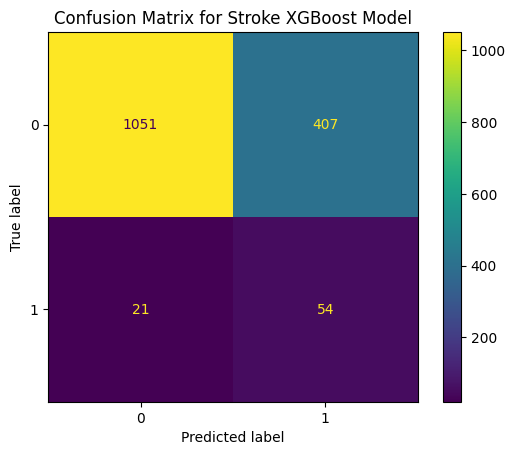

In [ ]:
# show the confusion matrix

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix for Stroke XGBoost Model")
plt.show()

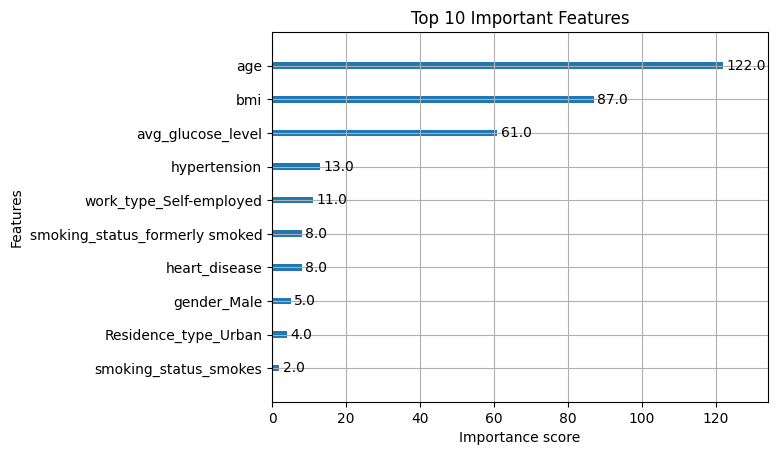

In [ ]:
# show the top 10 most important features

xgb.plot_importance(model, max_num_features=10)

plt.title("Top 10 Important Features")
plt.show()

For this dataset the goal was to predict whether a patient had a stroke or did not have a stroke. Most of the dataset was made up of people who did not have a stroke, with 4,861 no-stroke cases and only 249 stroke cases, so the data was very uneven. The code cleaned the data by removing the ID column, filling in missing BMI values, and changing text columns like gender, work type, and smoking status into numbers so the model could understand them.

The data was split into training and testing groups, then an XGBoost binary classification model was trained. The model had about 72% testing accuracy and a 72% recall score for stroke cases which means it was able to catch many of the actual stroke cases. However, the precision was low at about 11.7%, meaning the model also made a lot of false alarms. Overall, the model is useful for showing possible stroke risk, but it should not be used by itself for real medical decisions. It works more like an early warning tool that needs a person to check the results.